
# Steam Patch Notes — Descriptive Stats

This notebook focuses on:
- Descriptive statistics (with missingness)
- Distribution of patch notes across games
- “No patches” vs “Has patches”
- Relationship between **total news posts** and **total patch notes**

## Imports
Please note that following imports are required for this analysis

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
print(Path().resolve())

C:\Users\Saksham\Documents\Coding\Projects\Research\steam-patch-notes\statistics


## Loading Data

In [17]:

csv_path = Path("../output/games_metadata_totals.csv") 

df = pd.read_csv(csv_path)

C:\Users\Saksham\AppData\Local\Temp\ipykernel_62808\828370401.py:3: DtypeWarning: Columns (3,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


In [18]:
# Creating columns to convert to numeric
numeric_cols = [
    "total_news", "total_patches"
]

# Convert to numeric safely
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


## Computing Stats

In [19]:

# --- Compute descriptive statistics ---
desc_stats = df[numeric_cols].describe()
desc_stats.loc["total"] = df[numeric_cols].sum()
desc_stats.loc["missing_news", "total_news"] = df["total_news"].isna().sum()
desc_stats.loc["missing_patches", "total_patches"] = df["total_patches"].isna().sum()
desc_stats.loc["zero_news", "total_news"] = (df["total_news"]==0).sum()
desc_stats.loc["zero_patches", "total_patches"] = (df["total_patches"]==0).sum()

print(desc_stats)

# Save to CSV
desc_stats.to_csv("desc_stats_news_patches.csv")

                   total_news  total_patches
count            1.430880e+05   1.430880e+05
mean             1.324407e+01   7.620332e+00
std              5.749722e+01   3.378737e+01
min              0.000000e+00   0.000000e+00
25%              0.000000e+00   0.000000e+00
50%              2.000000e+00   1.000000e+00
75%              9.000000e+00   5.000000e+00
max              5.100000e+03   3.245000e+03
total            1.895067e+06   1.090378e+06
missing_news     2.534000e+03            NaN
missing_patches           NaN   2.534000e+03
zero_news        5.234600e+04            NaN
zero_patches              NaN   6.926400e+04


#### Notes / Findings
- The `missing_values` row shows how many entries are missing per numeric column.
- The `zero_values` row shows how many entries have 0 results per column.
- The games have same amount of missing news as patches


## Missing Values

In [20]:
missing_values = df[df["total_news"].isna()]
print(missing_values)

missing_values.to_csv("missing_values_news.csv")


                                       name  steam_appid  required_age  \
0                        FLOWorlds Playtest    3557900.0           0.0   
74                 Butterfly Dream Playtest    3116140.0           0.0   
109                Total Vengeance Playtest    2687580.0           0.0   
120                Leaf Blower Co. Playtest    3654790.0           0.0   
157                     Underquest Playtest    3239680.0           0.0   
...                                     ...          ...           ...   
145274                   Stardiver Playtest    3204670.0           0.0   
145289               HORROR TYCOON Playtest    1984300.0           0.0   
145404  World of Warships: Legends Playtest    3701470.0           0.0   
145468           DEAD LETTER DEPT. Playtest    3326430.0           0.0   
145591                 Radial Flow Playtest    2069590.0           0.0   

       is_free  number_dlc developers publishers price_currency  \
0        False         NaN        NaN       


### Notes / Findings
- All the games have Playtest at the end of there names
- No. of rows of df is aporox equal to no of games skipped at 403.

## Visualizations

### 1. Bar chart and log–log histogram of patch note counts and distribution

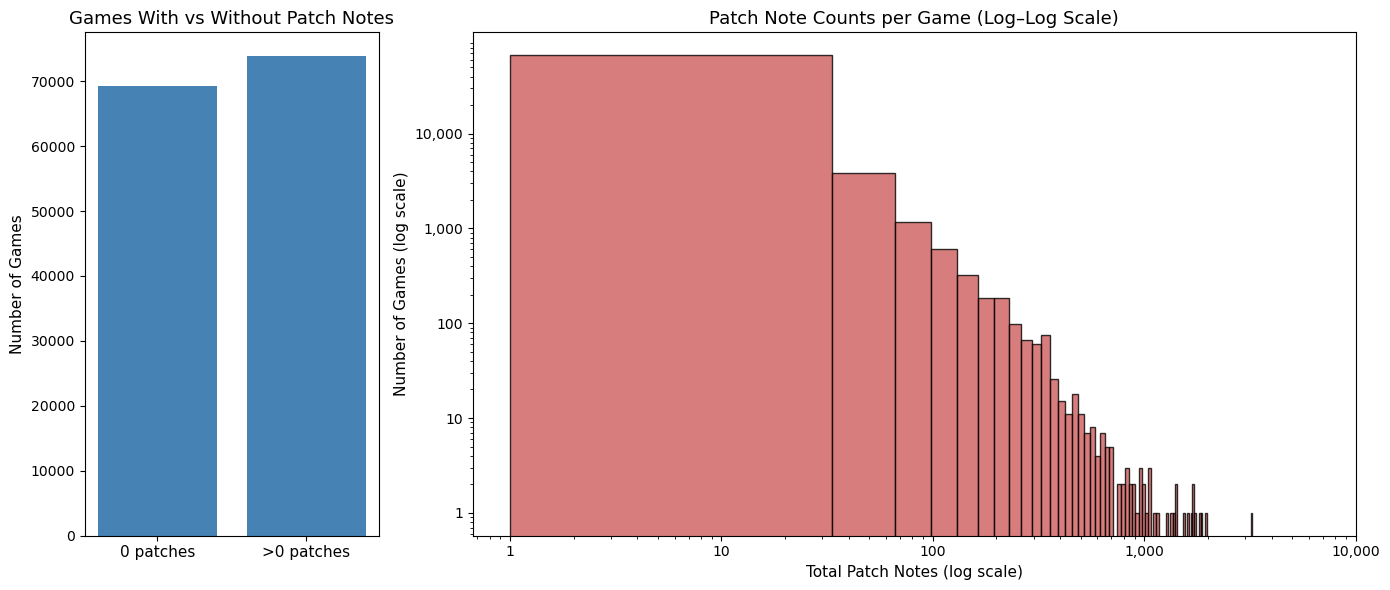

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 3]})

# --- Left side: Games with vs without patch notes ---
no_patch = df[df["total_patches"] == 0]
has_patch = df[df["total_patches"] > 0]

axes[0].bar(["0 patches"], [len(no_patch)], color="steelblue")
axes[0].bar([">0 patches"], [len(has_patch)], color="steelblue")
axes[0].set_title("Games With vs Without Patch Notes", fontsize=13)
axes[0].set_ylabel("Number of Games", fontsize=11)
axes[0].tick_params(axis='x', labelsize=11)
axes[0].tick_params(axis='y', labelsize=10)

# --- Right side: Log–log histogram of patch note counts ---
patch_counts = has_patch["total_patches"].dropna()

axes[1].hist(patch_counts, bins=100, color="indianred", edgecolor="black", alpha=0.8)
axes[1].set_xscale("log")
axes[1].set_yscale("log")

axes[1].set_title("Patch Note Counts per Game (Log–Log Scale)", fontsize=13)
axes[1].set_xlabel("Total Patch Notes (log scale)", fontsize=11)
axes[1].set_ylabel("Number of Games (log scale)", fontsize=11)

# Set ticks for better readability
axes[1].set_xticks([1, 10, 100, 1000, 10000])
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].set_yticks([1, 10, 100, 1000, 10000])
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Layout adjustment
plt.tight_layout()
plt.show()


#### Findings 
- The left panel shows how many games never published any patch notes (`0`) vs those that did (`>0`).
- The right panel indicates a distribution: most games have few patch notes; a small minority have hundreds or more.
- This pattern is consistent with platform dynamics where highly supported titles receive frequent updates.


### 2. Scatter plot: total_news vs total_patches with correlation

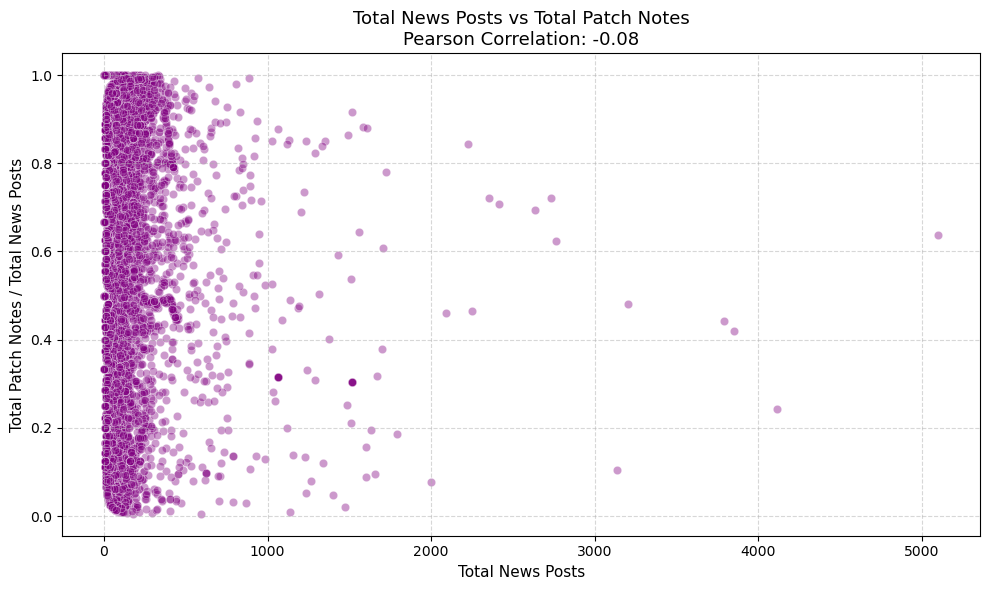

In [24]:
from scipy.stats import pearsonr

# Filter out rows with missing or zero data
df_clean = df.copy()
df_clean["total_news"] = pd.to_numeric(df_clean["total_news"], errors="coerce")
df_clean["total_patches/total_news"] = pd.to_numeric(df_clean["total_patches"], errors="coerce")/pd.to_numeric(df_clean["total_news"], errors="coerce")
df_clean = df_clean.dropna(subset=["total_news", "total_patches/total_news"])
df_clean = df_clean[(df_clean["total_news"] > 0) & (df_clean["total_patches/total_news"] > 0)]

# Compute correlation
corr, _ = pearsonr(df_clean["total_news"], df_clean["total_patches/total_news"])

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="total_news",
    y="total_patches/total_news",
    alpha=0.4,
    color="purple"
)

plt.title(f"Total News Posts vs Total Patch Notes\nPearson Correlation: {corr:.2f}", fontsize=13)
plt.xlabel("Total News Posts", fontsize=11)
plt.ylabel("Total Patch Notes / Total News Posts", fontsize=11)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Findings
- We plot each game’s **news posts** versus **patch notes**.
- Typical expectation: a **positive** association (studios that communicate more also tend to patch more), with outliers (e.g., games with frequent patches but few news posts, or vice versa).
